#Лабораторная работа №2
## Поэлементные преобразования изображений

1. Считать цветное rgb изображение.
2. Преобразовать изображение в градации серого.
3. Написать функцию расчета нормализованной гистограммы.
4. Написать функцию реализации поэлементной обработки изображения.

> Функцию вида fun(Image, prepfun)  
Где prepfun  - конкретная функция препаирования, заданная в том или ином виде.

5. Рассчитать функцию эквализации гистограммы изображения. Применить её к изображению с помощью функции поэлементной обработки.
  *   Вход: изображение из пункта 2.
  *   Вывод: входное и результирующие изображение, их гистограммы и интергральные функции распределения соответственно.
6. Осуществить препарирование изображения с заданной препарирующей функцией.
  *   Вход: изображение из пункта 2.
  *   Вывод: входное и результирующие изображение и их гистограммы соответственно. График препарирующий функции.
  *   Пороги в препарирующей функции выбирать самостоятельно.

   
    
*Для работы с изображением использовать OpenCV (открытие, сохранение и т.д.). Для визуализации можно использовать matplotlib. Все необходимые для задания функции реализовавать самим, а не использовать готовые в OpenCV, если не указано обратного.*
  
  
  

---



> По всем вопросам писать на почту  ***cybersouls@yandex.ru*** или в ЛС в VK/tg




Ссылки на полезные ресурсы:

1.   [Методичка по поэлементным преобразованиям](http://repo.ssau.ru/bitstream/Metodicheskie-ukazaniya/Poelementnye-preobrazovaniya-izobrazhenii-Elektronnyi-resurs-elektron-metod-ukazaniya-k-lab-rabote-1-53793/1/%d0%a1%d0%b5%d1%80%d0%b3%d0%b5%d0%b5%d0%b2%20%d0%92.%d0%92.%20%d0%9f%d0%be%d1%8d%d0%bb%d0%b5%d0%bc%d0%b5%d0%bd%d1%82%d0%bd%d1%8b%d0%b5%20%d0%bf%d1%80%d0%b5%d0%be%d0%b1%d1%80%d0%b0%d0%b7%d0%be%d0%b2%d0%b0%d0%bd%d0%b8%d1%8f.pdf)
2.    [Документация OpenCV](https://docs.opencv.org/4.x/index.html)


# Варианты задания

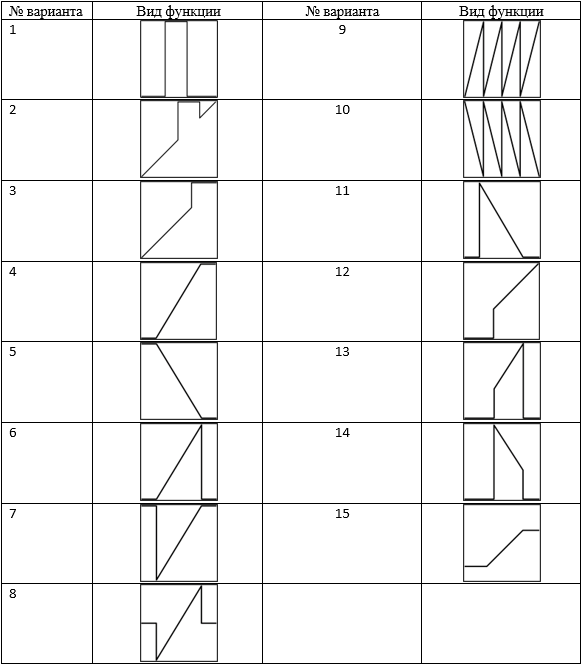

# Контрольные темы

1. Изображение. Основные понятия и определения. Представление изображений
в компьютере.
2. Гистограмма. Основные понятия.
3. Поэлементные преобразования изображений.
4. Пороговая обработка изображений.
5. Линейное контрастирование.
6. Преобразования гистогамм. Эквализация.
7. Препарирование изображений. Препарирующая функция.

Вариант 15

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

"""Считываем BGR изображение"""

image_bgr = cv2.imread('cats3.jpg')
if image_bgr is None:
    raise FileNotFoundError("Изображение не найдено, проверьте путь!")

plt.imshow(image_bgr)
plt.title("Оригинально изображение")
plt.axis('off')
plt.show()


[ WARN:0@0.027] global loadsave.cpp:278 findDecoder imread_('cats3.jpg'): can't open/read file: check file path/integrity


FileNotFoundError: Изображение не найдено, проверьте путь!

In [ ]:
"""Преобразовываем в Ч/Б"""

def bgr_to_gray(image_bgr: np.ndarray) -> np.ndarray:
    b, g, r = image_bgr[:, :, 0], image_bgr[:, :, 1], image_bgr[:, :, 2]
    gray_image = 0.299 * r + 0.587 * g + 0.114 * b
    gray_image = np.uint8(gray_image)
    return gray_image

gray_image = bgr_to_gray(image_bgr)

plt.imshow(gray_image, cmap='gray')
plt.title("Градации серого (ручной подход)")
plt.axis('off')
plt.show()


In [ ]:
"""Функция расчета нормализованной гистограммы"""

def normalized_histogram(image: list) -> list:
    hist = [0] * 256  # инициализируем гистограмму нулями
    rows = len(image)
    cols = len(image[0]) if rows > 0 else 0
    total_pixels = rows * cols  # общее количество пикселей

    # Проходим по всем пикселям изображения
    for row in image:
        for pixel in row:
            # на всякий случай проверим пиксель
            if 0 <= pixel < 256:
                hist[pixel] += 1

    # нормируем гистограмму
    if total_pixels > 0:
        hist = [x / total_pixels for x in hist]
    return hist

hist_gray = normalized_histogram(gray_image)

plt.bar(np.arange(256), hist_gray, width=1)
plt.title("Нормализованная гистограмма (градации серого)")
plt.xlabel("Уровень яркости")
plt.ylabel("Вероятность")
plt.show()


In [ ]:
"""Функция поэлементной обработки изображения"""

def point_transform(image: list, prepfun) -> list:
    """Для каждого пикселя применяем prepfun и возвращаем новое изображение"""
    result = []
    for row in image:
        new_row = []
        for pixel in row:
            new_row.append(prepfun(pixel))
        result.append(new_row)
    return result


In [ ]:
"""Функция эквализации гистограммы"""

def equalization_mapping(hist: list):
    """Принимает нормированную гистограмму hist и
    возвращает mapping (лут) и cdf (накопленное распределение)."""
    cdf = [0] * 256
    cdf[0] = hist[0]

    for i in range(1, 256):
        cdf[i] = cdf[i - 1] + hist[i]

    # строим отображение эквализации
    # на всякий случай берём int, если нужно
    mapping = [int(255 * val) for val in cdf]

    return mapping, cdf

mapping_eq, cdf_eq = equalization_mapping(hist_gray)

plt.plot(cdf_eq)
plt.title("Интегральная функция распределения (CDF)")
plt.xlabel("Яркость")
plt.ylabel("Накопленная вероятность")
plt.show()

plt.plot(mapping_eq)
plt.title("Функция эквализации гистограммы")
plt.xlabel("Яркость")
plt.ylabel("Новое значение")
plt.show()


In [ ]:
"""Применение функции эквализации гистограммы с помощью функции поэлементной обработки"""

def prepfun_eq(value):
    return mapping_eq[value]

equalized_image = point_transform(gray_image, prepfun_eq)
hist_equalized = normalized_histogram(equalized_image)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

axes[0, 0].imshow(gray_image, cmap='gray')
axes[0, 0].set_title("Исходное изображение")
axes[0, 0].axis('off')

axes[0, 1].imshow(equalized_image, cmap='gray')
axes[0, 1].set_title("Эквализованное изображение")
axes[0, 1].axis('off')

axes[0, 2].plot(cdf_eq)
axes[0, 2].set_title("Интегральная функция (CDF)")
axes[0, 2].set_xlabel("Яркость")
axes[0, 2].set_ylabel("Накопленная вероятность")

axes[1, 0].bar(np.arange(256), hist_gray, width=1)
axes[1, 0].set_title("Гистограмма исходного изображения")

axes[1, 1].bar(np.arange(256), hist_equalized, width=1)
axes[1, 1].set_title("Гистограмма эквализованного изображения")

axes[1, 2].plot(mapping_eq)
axes[1, 2].set_title("Функция эквализации")
axes[1, 2].set_xlabel("Яркость")
axes[1, 2].set_ylabel("Новое значение")

plt.tight_layout()
plt.show()

# Отображение CDF эквализованного изображения
_, cdf_eq_image = equalization_mapping(hist_equalized)
plt.plot(cdf_eq_image)
plt.title("Интегральная функция распределения (CDF) изображения")
plt.xlabel("Яркость")
plt.ylabel("Накопленная вероятность")
plt.show()


In [ ]:
def custom_func(a, c):
    def func(x):
        x = int(x)
        if x < a:
            return 0
        return int(c + (255 - c) * (x - a) / (255 - a))
    return func

prepfun_custom = custom_func(a=80, c=70)
custom_image = np.array(point_transform(gray_image, prepfun_custom), dtype=np.uint8)
hist_custom = normalized_histogram(custom_image)

prepfun_custom = custom_func(a=80, c=70)
custom_image = np.array(point_transform(gray_image, prepfun_custom), dtype=np.uint8)
hist_custom = normalized_histogram(custom_image)

In [ ]:
prepfun_custom = custom_func(150, 200)

# Визуализация моей препарирующей функции по варианту
x_vals = np.arange(256)
y_vals = np.array([prepfun_custom(x) for x in x_vals])

plt.plot(x_vals, y_vals)
plt.title("Custom препарирующая функция")
plt.xlabel("Входное значение")
plt.ylabel("Выходное значение")
plt.show()

"""Препарирование изображения с помощью функции по варианту (2)"""

max(hist_gray)



custom_image = point_transform(gray_image, prepfun_custom)
hist_custom = normalized_histogram(custom_image)

max(hist_custom)

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

axes[0].imshow(gray_image, cmap='gray')
axes[0].set_title("Исходное изображение")
axes[0].axis('off')

axes[1].imshow(custom_image, cmap='gray')
axes[1].set_title("Custom обработка")
axes[1].axis('off')

axes[2].bar(np.arange(256), hist_gray, width=1)
axes[2].set_title("Гистограмма исходного изображения")

axes[3].bar(np.arange(256), hist_custom, width=1)
axes[3].set_title("Гистограмма Custom изображения")

# Подравниваем по одной шкале Y
axes[3].set_ylim(axes[2].get_ylim())

plt.tight_layout()
plt.show()



In [ ]:

np.unique(custom_image )

In [ ]:


prepfun_custom = custom_func(150, 200)

# Визуализация моей препарирующей функции по варианту
x_vals = np.arange(256)
y_vals = np.array([prepfun_custom(x) for x in x_vals])

plt.plot(x_vals, y_vals)
plt.title("Custom препарирующая функция")
plt.xlabel("Входное значение")
plt.ylabel("Выходное значение")
plt.show()

"""Препарирование изображения с помощью функции по варианту (2)"""

max(hist_gray)

max(hist_custom)

custom_image = point_transform(gray_image, prepfun_custom)
hist_custom = normalized_histogram(custom_image)

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

axes[0].imshow(gray_image, cmap='gray')
axes[0].set_title("Исходное изображение")
axes[0].axis('off')

axes[1].imshow(custom_image, cmap='gray')
axes[1].set_title("Custom обработка")
axes[1].axis('off')

axes[2].bar(np.arange(256), hist_gray, width=1)
axes[2].set_title("Гистограмма исходного изображения")

axes[3].bar(np.arange(256), hist_custom, width=1)
axes[3].set_title("Гистограмма Custom изображения")

# Подравниваем по одной шкале Y
axes[3].set_ylim(axes[2].get_ylim())

plt.tight_layout()
plt.show()
